# Machine Learning Training Section

Support Vector Machine, Gradient Boosted Trees, and Random Forest

 1. **Split** the dataset for testing and validation into folds.
 1. **Select** a machine learning algorithm to be tested with the dataset by importing a specific machine learning algorithm in scikit-learn library.
 1. **Train** using the training folds and will be tested and evaluated using the validation folds wherein the researchers will also observe its accuracy, detection rate, recall, precision, false positive rate and take the average of it.
 1. **Evaluate** the combinations of the hyperparameters to maximize the performance of the model.          
 *If the best combination is found, then it will proceed to the next step. If not, then it will undergo hyperparameter tuning to find the best combination of the hyperparameters and will undergo training with the tuned hyperparameters.*
 1. The model will then be compared with the performance of other models to determine the best based on the given evaluation metrics.
 1. The best performing model will be then tested using the testing set that is still unseen by the model.

**Input** -===- Preprocessed Dataset

**Output** -==- Model & Scaler Output

In [24]:
# @title
!nvidia-smi

Tue Jul 14 10:58:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P0             28W /   70W |     423MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [25]:
# @title
%load_ext cuml.accel


The cuml.accel extension is already loaded. To reload it, use:
  %reload_ext cuml.accel


In [26]:
# @title
%pip install pandas numpy matplotlib scikit-learn imbalanced-learn

In [27]:
# @title
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import mutual_info_classif
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from matplotlib.colors import LogNorm
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, confusion_matrix

from sklearn.preprocessing import StandardScaler

from google.colab import drive
drive.mount('/content/drive')
!ls "/content/drive/My Drive/zeek24data"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 before				   check_remove_irrelevant.csv
 Benign,Ca,Discovery,RD		   final_train.csv
 check_binning_of_continuous.csv  'final_train(no upsample).csv'
 check_binning_of_ports.csv	   infogain_MC.csv
 check_boolean_encoding.csv	   rd_final_train.csv
 check_data_cleaning.csv	   rd_test.csv
 check_drop_original.csv	   test.csv
 check_drop_zero_infogain.csv	  'test(no upsample).csv'
 check_keep_reconnaissance.csv	   train.csv
 check_onehot_categorical.csv	  'train(no upsample).csv'
 check_onehot_continuous.csv	   zeekdata_combined.csv
 check_onehot_ports.csv		   zeekdatasets


In [28]:
# @title
from sklearn.metrics import make_scorer, confusion_matrix

def multiclass_weighted_fpr(y_true, y_pred):
    """Calculates the weighted False Positive Rate for multiclass classification."""
    cm = confusion_matrix(y_true, y_pred)

    # FP: Column sum - TP (diagonal)
    fp = cm.sum(axis=0) - np.diag(cm)
    # FN: Row sum - TP (diagonal)
    fn = cm.sum(axis=1) - np.diag(cm)
    # TP: Diagonal
    tp = np.diag(cm)
    # TN: Total - (FP + FN + TP)
    tn = cm.sum() - (fp + fn + tp)

    # FPR = FP / (FP + TN)
    fpr = fp / (fp + tn)

    # Handle potential division by zero
    fpr = np.nan_to_num(fpr)

    # Return weighted average based on class support (row sums)
    weights = cm.sum(axis=1)
    return np.average(fpr, weights=weights)

# Create the scorer object
fpr_scorer = make_scorer(multiclass_weighted_fpr)

In [29]:
##### FOR COLAB #####
train = "/content/drive/MyDrive/zeek24data/rd_final_train.csv"
test = "/content/drive/MyDrive/zeek24data/rd_test.csv"
'''
train = "/content/train_binary.csv"
test = "/content/test_binary.csv"

train = "../datasets/final_train.csv"
test = "../datasets/test.csv"
'''

df = pd.read_csv(train)
test_df = pd.read_csv(test)

df.head()



,local_resp,src_port_bin_1,src_port_bin_2,src_port_bin_3,dest_port_bin_1,dest_port_bin_2,dest_port_bin_3,duration_bin_0.0,duration_bin_1.0,duration_bin_2.0,...,service_dce_rpc,service_dns,service_ftp,service_gssapi,service_http,service_krb_tcp,service_ntp,service_ssl,service_unknown,label_tactic
0,0,0,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,1,0,Credential Access
1,0,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,Credential Access
2,0,0,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,1,0,Credential Access
3,0,0,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,1,0,Credential Access
4,0,0,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,1,0,Credential Access


In [30]:
df = df.drop(df.columns[0], axis=1)
test_df = test_df.drop(test_df.columns[0], axis=1)
df.head()

,src_port_bin_1,src_port_bin_2,src_port_bin_3,dest_port_bin_1,dest_port_bin_2,dest_port_bin_3,duration_bin_0.0,duration_bin_1.0,duration_bin_2.0,duration_bin_3.0,...,service_dce_rpc,service_dns,service_ftp,service_gssapi,service_http,service_krb_tcp,service_ntp,service_ssl,service_unknown,label_tactic
0,0,1,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,Credential Access
1,0,1,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,Credential Access
2,0,1,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,Credential Access
3,0,1,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,Credential Access
4,0,1,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,Credential Access


In [31]:
X_train = df.drop(columns=["label_tactic"])
y_train = df["label_tactic"]

X_test = test_df.drop(columns=["label_tactic"])
y_test = test_df["label_tactic"]
X_train.head()

,src_port_bin_1,src_port_bin_2,src_port_bin_3,dest_port_bin_1,dest_port_bin_2,dest_port_bin_3,duration_bin_0.0,duration_bin_1.0,duration_bin_2.0,duration_bin_3.0,...,history_^r,service_dce_rpc,service_dns,service_ftp,service_gssapi,service_http,service_krb_tcp,service_ntp,service_ssl,service_unknown
0,0,1,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,1,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,0,1,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
3,0,1,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,1,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0


In [32]:
'''
X_train = df.drop(columns=["label_binary_class"])
y_train = df["label_binary_class"]

X_test = test_df.drop(columns=["label_binary_class"])
y_test = test_df["label_binary_class"]
'''

'\nX_train = df.drop(columns=["label_binary_class"])\ny_train = df["label_binary_class"]\n\nX_test = test_df.drop(columns=["label_binary_class"])\ny_test = test_df["label_binary_class"]\n'

In [33]:
# @title
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
# @title
from sklearn.model_selection import cross_validate, StratifiedKFold, GridSearchCV
from sklearn.svm import LinearSVC

svm = LinearSVC(
    C= 0.1,
    loss = 'squared_hinge',
    max_iter=1000,
    tol=1e-4,
    dual=True
)

scoring = {
    'accuracy': 'accuracy',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted',
    'f1_weighted': 'f1_weighted',
    'fpr_weighted': fpr_scorer
}

skf_10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_results = cross_validate(
    svm,
    X_train_scaled,
    y_train,
    cv=skf_10,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

cv_df = pd.DataFrame({
    "fold": np.arange(1, 11),
    "train_accuracy": cv_results["train_accuracy"],
    "test_accuracy": cv_results["test_accuracy"],
    "train_precision_weighted": cv_results["train_precision_weighted"],
    "test_precision_weighted": cv_results["test_precision_weighted"],
    "train_recall_weighted": cv_results["train_recall_weighted"],
    "test_recall_weighted": cv_results["test_recall_weighted"],
    "train_f1_weighted": cv_results["train_f1_weighted"],
    "test_f1_weighted": cv_results["test_f1_weighted"],
    "fit_time_sec": cv_results["fit_time"],
    "score_time_sec": cv_results["score_time"],
    "train_fpr": cv_results["train_fpr_weighted"],
    "test_fpr": cv_results["test_fpr_weighted"],
})

print("10-Fold Cross-Validation (Fold-by-Fold):")
print(cv_df.round(4).to_string(index=False))

print("\nSummary (test metrics):")
for metric in ["test_accuracy", "test_precision_weighted", "test_recall_weighted", "test_f1_weighted"]:
    vals = cv_results[metric]
    print(f"{metric}: mean={vals.mean():.4f}, std={vals.std():.4f}, min={vals.min():.4f}, max={vals.max():.4f}")

print("\nGeneralization gap (train - test, mean):")
for metric in ["accuracy", "precision_weighted", "recall_weighted", "f1_weighted"]:
    gap = cv_results[f"train_{metric}"].mean() - cv_results[f"test_{metric}"].mean()
    print(f"{metric}: {gap:.4f}")

param_grid = [
    {
        'loss': ['hinge'],
        'dual': [True],
        'C': [0.01, 0.1, 1, 10, 100],
        'tol': [1e-4, 1e-3, 1e-2],
        'max_iter': [1000, 5000, 10000],
    },
    {
        'loss': ['squared_hinge'],
        'dual': [True, False],
        'C': [0.01, 0.1, 1, 10, 100],
        'tol': [1e-4, 1e-3, 1e-2],
        'max_iter': [1000, 5000, 10000],
    }
]

grid_search = GridSearchCV(
    LinearSVC(class_weight='balanced', random_state=42),
    param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")


10-Fold Cross-Validation (Fold-by-Fold):
 fold  train_accuracy  test_accuracy  train_precision_weighted  test_precision_weighted  train_recall_weighted  test_recall_weighted  train_f1_weighted  test_f1_weighted  fit_time_sec  score_time_sec  train_fpr  test_fpr
    1          0.9136         0.9127                    0.8598                   0.8592                 0.9136                0.9127             0.8828            0.8820        2.7632          1.8043     0.0462    0.0467
    2          0.9133         0.9153                    0.8949                   0.8609                 0.9133                0.9153             0.8826            0.8844        2.7181          1.8240     0.0463    0.0453
    3          0.9136         0.9130                    0.8598                   0.8595                 0.9136                0.9130             0.8828            0.8823        1.2070          0.8489     0.0462    0.0465
    4          0.9135         0.9135                    0.8597             

In [35]:
# @title
from sklearn.metrics import cohen_kappa_score, precision_recall_curve, auc, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
from scipy.special import softmax

svm = grid_search.best_estimator_
y_pred = svm.predict(X_test_scaled)
# LinearSVC doesn't have predict_proba, so use decision_function and convert to probabilities
y_pred_proba = svm.decision_function(X_test_scaled)
# Normalize to [0, 1] range using softmax-like transformation
y_pred_proba = softmax(y_pred_proba, axis=1)

kappa = cohen_kappa_score(y_test, y_pred)
print(f"Cohen's Kappa Score: {kappa:.4f}")

classes = sorted(np.unique(y_test))
n_classes = len(classes)

y_test_bin = label_binarize(y_test, classes=classes)

print("\nPer-Class Metrics:")
print(f"{'Class':<25} {'PR-AUC':<12} {'ROC-AUC':<12}")
print("-" * 50)

pr_auc_scores = []
roc_auc_scores = []

for i, cls in enumerate(classes):
    try:
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
        pr_auc = auc(recall, precision)
        pr_auc_scores.append(pr_auc)

        roc_auc = roc_auc_score(y_test_bin[:, i], y_pred_proba[:, i])
        roc_auc_scores.append(roc_auc)

        print(f"{cls:<25} {pr_auc:<12.4f} {roc_auc:<12.4f}")
    except Exception as e:
        print(f"{cls:<25} Error: {str(e)}")

print("-" * 50)
print(f"{'Macro Average':<25} {np.mean(pr_auc_scores):<12.4f} {np.mean(roc_auc_scores):<12.4f}")
print(f"{'Weighted Average':<25} {np.average(pr_auc_scores, weights=np.sum(y_test_bin, axis=0)):<12.4f} {np.average(roc_auc_scores, weights=np.sum(y_test_bin, axis=0)):<12.4f}")

print(classification_report(y_test, y_pred))

Cohen's Kappa Score: 0.8265

Per-Class Metrics:
Class                     PR-AUC       ROC-AUC     
--------------------------------------------------
Credential Access         1.0000       1.0000      
Discovery                 0.7845       0.9511      
Resource Development      0.2515       0.9146      
none                      0.9980       0.9976      
--------------------------------------------------
Macro Average             0.7585       0.9658      
Weighted Average          0.9045       0.9817      
                      precision    recall  f1-score   support

   Credential Access       1.00      1.00      1.00      8699
           Discovery       0.80      0.76      0.78     13431
Resource Development       0.29      0.50      0.37      2723
                none       1.00      0.96      0.98     27403

            accuracy                           0.89     52256
           macro avg       0.77      0.80      0.78     52256
        weighted avg       0.91      0.89      0.9

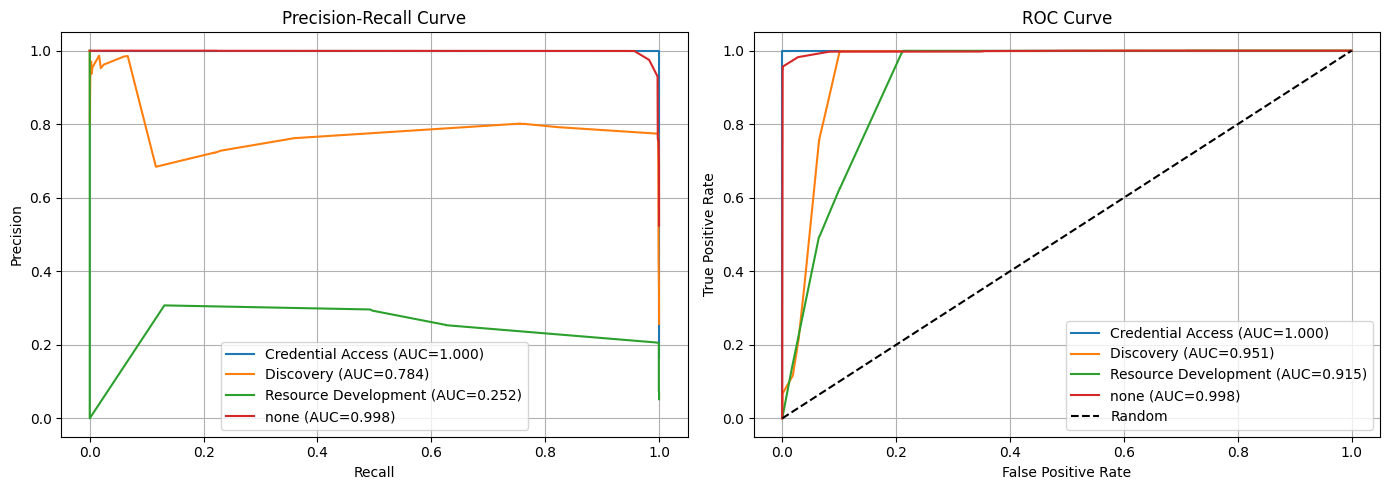

In [36]:
# @title
from sklearn.metrics import precision_recall_curve, roc_curve, auc
from sklearn.preprocessing import label_binarize

y_pred_scores = grid_search.best_estimator_.decision_function(X_test_scaled)
y_pred_proba = softmax(y_pred_scores, axis=1)
classes = sorted(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=classes)

# subplots for PR and ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# plot PR
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
    pr_auc = auc(recall, precision)
    axes[0].plot(recall, precision, label=f'{cls} (AUC={pr_auc:.3f})')

axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend(loc='best')
axes[0].grid(True)

# plot ROC
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f'{cls} (AUC={roc_auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='best')
axes[1].grid(True)

plt.tight_layout()
plt.show()


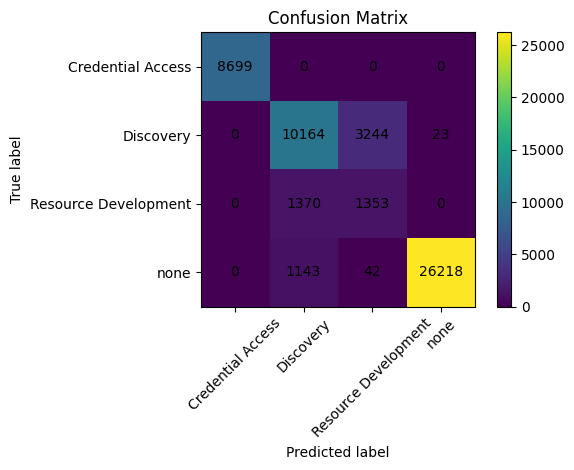

In [37]:
from sklearn.metrics import confusion_matrix

y_pred = grid_search.best_estimator_.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.clim(0, cm.max())
class_names = sorted(np.unique(y_test))
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

In [38]:
best_model = grid_search.best_estimator_


y_pred = best_model.predict(X_test_scaled)
y_true = y_test

analysis_df = test_df.reset_index(drop=True).copy()

analysis_df["True Class"] = y_true.reset_index(drop=True)
analysis_df["Predicted Class"] = pd.Series(y_pred).reset_index(drop=True)

classes = sorted(y_true.unique())

for true_class in classes:
    for pred_class in classes:

        if true_class == pred_class:
            continue

        mask = (
            (analysis_df["True Class"] == true_class) &
            (analysis_df["Predicted Class"] == pred_class)
        )

        if mask.sum() == 0:
            continue

        subset = analysis_df.loc[mask].drop(
            columns=["True Class", "Predicted Class"],
            errors="ignore"
        )

        print("=" * 100)
        print(f"{true_class} ---> {pred_class}")
        print(f"Misclassified Samples: {len(subset)}")

        common_columns = {}

        for col in subset.columns:

            if pd.api.types.is_float_dtype(subset[col]):
                continue

            values = subset[col].dropna().unique()

            if len(values) == 1:
                common_columns[col] = values[0]

        if common_columns:
            print("\nCommon Columns:")
            for col, value in common_columns.items():
                print(f"{col}: {value}")
        else:
            print("\nNo columns have identical values across every sample.")

        display(subset)

Discovery ---> Resource Development
Misclassified Samples: 3244

Common Columns:
label_tactic: Discovery
src_port_bin_1: 0
duration_bin_2.0: 0
duration_bin_3.0: 0
duration_bin_4.0: 0
duration_bin_5.0: 0
duration_bin_6.0: 0
missed_bytes_bin_1.0: 1
missed_bytes_bin_3.0: 0
orig_ip_bytes_bin_1.0: 1
orig_ip_bytes_bin_2.0: 0
orig_ip_bytes_bin_3.0: 0
orig_ip_bytes_bin_4.0: 0
orig_ip_bytes_bin_5.0: 0
orig_ip_bytes_bin_6.0: 0
orig_pkts_bin_1.0: 1
orig_pkts_bin_2.0: 0
orig_pkts_bin_3.0: 0
orig_pkts_bin_4.0: 0
orig_pkts_bin_5.0: 0
orig_pkts_bin_6.0: 0
resp_bytes_bin_3.0: 0
resp_bytes_bin_4.0: 0
resp_bytes_bin_6.0: 0
resp_ip_bytes_bin_1.0: 1
resp_ip_bytes_bin_3.0: 0
resp_ip_bytes_bin_4.0: 0
resp_ip_bytes_bin_6.0: 0
resp_pkts_bin_1.0: 1
resp_pkts_bin_2.0: 0
resp_pkts_bin_3.0: 0
resp_pkts_bin_4.0: 0
resp_pkts_bin_5.0: 0
resp_pkts_bin_6.0: 0
conn_state_REJ: 0
conn_state_RSTRH: 0
conn_state_SH: 0
conn_state_SHR: 0
proto_tcp: 1
proto_udp: 0
history_Ar: 0
history_Arr: 0
history_D: 0
history_Dd: 0
histor

,label_tactic,src_port_bin_1,src_port_bin_2,src_port_bin_3,dest_port_bin_1,dest_port_bin_2,dest_port_bin_3,duration_bin_0.0,duration_bin_1.0,duration_bin_2.0,...,history_^r,service_dce_rpc,service_dns,service_ftp,service_gssapi,service_http,service_krb_tcp,service_ntp,service_ssl,service_unknown
4,Discovery,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
22,Discovery,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
30,Discovery,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
37,Discovery,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
65,Discovery,0,0,1,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52138,Discovery,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
52160,Discovery,0,0,1,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1
52162,Discovery,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
52188,Discovery,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1


Discovery ---> none
Misclassified Samples: 23

Common Columns:
label_tactic: Discovery
src_port_bin_1: 0
duration_bin_0.0: 0
duration_bin_3.0: 0
duration_bin_4.0: 0
duration_bin_5.0: 0
duration_bin_6.0: 0
missed_bytes_bin_3.0: 0
orig_bytes_bin_0.0: 0
orig_ip_bytes_bin_1.0: 1
orig_ip_bytes_bin_2.0: 0
orig_ip_bytes_bin_3.0: 0
orig_ip_bytes_bin_4.0: 0
orig_ip_bytes_bin_5.0: 0
orig_ip_bytes_bin_6.0: 0
orig_pkts_bin_1.0: 1
orig_pkts_bin_2.0: 0
orig_pkts_bin_3.0: 0
orig_pkts_bin_4.0: 0
orig_pkts_bin_5.0: 0
orig_pkts_bin_6.0: 0
resp_bytes_bin_0.0: 0
resp_bytes_bin_1.0: 1
resp_bytes_bin_3.0: 0
resp_bytes_bin_4.0: 0
resp_bytes_bin_6.0: 0
resp_ip_bytes_bin_1.0: 1
resp_ip_bytes_bin_3.0: 0
resp_ip_bytes_bin_4.0: 0
resp_ip_bytes_bin_6.0: 0
resp_pkts_bin_1.0: 1
resp_pkts_bin_2.0: 0
resp_pkts_bin_3.0: 0
resp_pkts_bin_4.0: 0
resp_pkts_bin_5.0: 0
resp_pkts_bin_6.0: 0
conn_state_REJ: 0
conn_state_S0: 0
conn_state_SHR: 0
history_Ar: 0
history_D: 0
history_Hs^ADTdttTaFf: 0
history_Q: 0
history_S: 0
histor

,label_tactic,src_port_bin_1,src_port_bin_2,src_port_bin_3,dest_port_bin_1,dest_port_bin_2,dest_port_bin_3,duration_bin_0.0,duration_bin_1.0,duration_bin_2.0,...,history_^r,service_dce_rpc,service_dns,service_ftp,service_gssapi,service_http,service_krb_tcp,service_ntp,service_ssl,service_unknown
314,Discovery,0,0,1,1,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
3711,Discovery,0,1,0,1,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
3717,Discovery,0,1,0,0,0,1,0,1,0,...,0,1,0,0,0,0,0,0,0,0
6477,Discovery,0,1,0,1,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
7983,Discovery,0,1,0,1,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
10092,Discovery,0,0,1,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
10883,Discovery,0,1,0,1,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
11911,Discovery,0,1,0,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
15190,Discovery,0,1,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
18314,Discovery,0,1,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1


Resource Development ---> Discovery
Misclassified Samples: 1370

Common Columns:
label_tactic: Resource Development
src_port_bin_1: 0
src_port_bin_2: 1
src_port_bin_3: 0
duration_bin_2.0: 0
duration_bin_3.0: 0
duration_bin_4.0: 0
duration_bin_5.0: 0
duration_bin_6.0: 0
missed_bytes_bin_1.0: 1
missed_bytes_bin_3.0: 0
orig_ip_bytes_bin_1.0: 1
orig_ip_bytes_bin_2.0: 0
orig_ip_bytes_bin_3.0: 0
orig_ip_bytes_bin_4.0: 0
orig_ip_bytes_bin_5.0: 0
orig_ip_bytes_bin_6.0: 0
orig_pkts_bin_1.0: 1
orig_pkts_bin_2.0: 0
orig_pkts_bin_3.0: 0
orig_pkts_bin_4.0: 0
orig_pkts_bin_5.0: 0
orig_pkts_bin_6.0: 0
resp_bytes_bin_3.0: 0
resp_bytes_bin_4.0: 0
resp_bytes_bin_6.0: 0
resp_ip_bytes_bin_1.0: 1
resp_ip_bytes_bin_3.0: 0
resp_ip_bytes_bin_4.0: 0
resp_ip_bytes_bin_6.0: 0
resp_pkts_bin_1.0: 1
resp_pkts_bin_2.0: 0
resp_pkts_bin_3.0: 0
resp_pkts_bin_4.0: 0
resp_pkts_bin_5.0: 0
resp_pkts_bin_6.0: 0
conn_state_REJ: 0
conn_state_RSTRH: 0
conn_state_SH: 0
conn_state_SHR: 0
proto_tcp: 1
proto_udp: 0
history_Ar: 0
h

,label_tactic,src_port_bin_1,src_port_bin_2,src_port_bin_3,dest_port_bin_1,dest_port_bin_2,dest_port_bin_3,duration_bin_0.0,duration_bin_1.0,duration_bin_2.0,...,history_^r,service_dce_rpc,service_dns,service_ftp,service_gssapi,service_http,service_krb_tcp,service_ntp,service_ssl,service_unknown
48,Resource Development,0,1,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
127,Resource Development,0,1,0,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1
138,Resource Development,0,1,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
219,Resource Development,0,1,0,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1
231,Resource Development,0,1,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52025,Resource Development,0,1,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
52182,Resource Development,0,1,0,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1
52214,Resource Development,0,1,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
52234,Resource Development,0,1,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1


none ---> Discovery
Misclassified Samples: 1143

Common Columns:
label_tactic: none
src_port_bin_1: 0
dest_port_bin_3: 0
duration_bin_2.0: 0
duration_bin_3.0: 0
duration_bin_4.0: 0
duration_bin_5.0: 0
duration_bin_6.0: 0
missed_bytes_bin_1.0: 1
missed_bytes_bin_3.0: 0
orig_ip_bytes_bin_1.0: 1
orig_ip_bytes_bin_2.0: 0
orig_ip_bytes_bin_3.0: 0
orig_ip_bytes_bin_4.0: 0
orig_ip_bytes_bin_5.0: 0
orig_ip_bytes_bin_6.0: 0
orig_pkts_bin_1.0: 1
orig_pkts_bin_2.0: 0
orig_pkts_bin_3.0: 0
orig_pkts_bin_4.0: 0
orig_pkts_bin_5.0: 0
orig_pkts_bin_6.0: 0
resp_bytes_bin_3.0: 0
resp_bytes_bin_4.0: 0
resp_bytes_bin_6.0: 0
resp_ip_bytes_bin_1.0: 1
resp_ip_bytes_bin_3.0: 0
resp_ip_bytes_bin_4.0: 0
resp_ip_bytes_bin_6.0: 0
resp_pkts_bin_1.0: 1
resp_pkts_bin_2.0: 0
resp_pkts_bin_3.0: 0
resp_pkts_bin_4.0: 0
resp_pkts_bin_5.0: 0
resp_pkts_bin_6.0: 0
conn_state_RSTRH: 0
conn_state_SF: 0
conn_state_SHR: 0
proto_tcp: 1
proto_udp: 0
history_Ar: 0
history_Arr: 0
history_D: 0
history_Dd: 0
history_Hs^ADTdttTaFf: 0
h

,label_tactic,src_port_bin_1,src_port_bin_2,src_port_bin_3,dest_port_bin_1,dest_port_bin_2,dest_port_bin_3,duration_bin_0.0,duration_bin_1.0,duration_bin_2.0,...,history_^r,service_dce_rpc,service_dns,service_ftp,service_gssapi,service_http,service_krb_tcp,service_ntp,service_ssl,service_unknown
69,none,0,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
92,none,0,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
242,none,0,0,1,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
289,none,0,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
320,none,0,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52101,none,0,0,1,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
52143,none,0,1,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
52229,none,0,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
52242,none,0,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1


none ---> Resource Development
Misclassified Samples: 42

Common Columns:
label_tactic: none
src_port_bin_1: 0
src_port_bin_2: 0
src_port_bin_3: 1
duration_bin_0.0: 1
duration_bin_1.0: 0
duration_bin_2.0: 0
duration_bin_3.0: 0
duration_bin_4.0: 0
duration_bin_5.0: 0
duration_bin_6.0: 0
missed_bytes_bin_1.0: 1
missed_bytes_bin_3.0: 0
orig_bytes_bin_0.0: 1
orig_bytes_bin_1.0: 0
orig_ip_bytes_bin_1.0: 1
orig_ip_bytes_bin_2.0: 0
orig_ip_bytes_bin_3.0: 0
orig_ip_bytes_bin_4.0: 0
orig_ip_bytes_bin_5.0: 0
orig_ip_bytes_bin_6.0: 0
orig_pkts_bin_1.0: 1
orig_pkts_bin_2.0: 0
orig_pkts_bin_3.0: 0
orig_pkts_bin_4.0: 0
orig_pkts_bin_5.0: 0
orig_pkts_bin_6.0: 0
resp_bytes_bin_0.0: 1
resp_bytes_bin_1.0: 0
resp_bytes_bin_3.0: 0
resp_bytes_bin_4.0: 0
resp_bytes_bin_6.0: 0
resp_ip_bytes_bin_1.0: 1
resp_ip_bytes_bin_3.0: 0
resp_ip_bytes_bin_4.0: 0
resp_ip_bytes_bin_6.0: 0
resp_pkts_bin_1.0: 1
resp_pkts_bin_2.0: 0
resp_pkts_bin_3.0: 0
resp_pkts_bin_4.0: 0
resp_pkts_bin_5.0: 0
resp_pkts_bin_6.0: 0
conn_stat

,label_tactic,src_port_bin_1,src_port_bin_2,src_port_bin_3,dest_port_bin_1,dest_port_bin_2,dest_port_bin_3,duration_bin_0.0,duration_bin_1.0,duration_bin_2.0,...,history_^r,service_dce_rpc,service_dns,service_ftp,service_gssapi,service_http,service_krb_tcp,service_ntp,service_ssl,service_unknown
96,none,0,0,1,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1
209,none,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
1562,none,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
1720,none,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
2492,none,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
4997,none,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
5623,none,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
6639,none,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
9011,none,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
11371,none,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
